In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("dynamic_pricing_dataset.csv")

In [3]:
df

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,season,day_of_week,customer_rating,units_sold,optimal_price
0,1102,15.46,22.09,281,104,4773.30,winter,thursday,3.30,267,18.51
1,1435,29.58,17.53,191,122,2638.04,monsoon,thursday,4.53,141,29.76
2,1860,123.77,129.09,390,376,4808.98,monsoon,thursday,2.78,287,126.66
3,1270,123.38,135.49,424,449,1857.01,festival,wednesday,2.74,475,125.46
4,1106,55.74,70.18,107,644,1053.16,summer,monday,3.47,84,57.67
...,...,...,...,...,...,...,...,...,...,...,...
49995,1381,150.80,149.89,361,205,3334.23,monsoon,saturday,4.28,336,152.42
49996,1044,90.75,110.53,321,68,1930.42,monsoon,tuesday,3.12,298,93.69
49997,1916,144.35,144.23,140,145,2197.25,festival,friday,4.14,99,145.48
49998,1171,178.53,184.98,62,320,4419.28,summer,thursday,4.79,65,181.44


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        50000 non-null  int64  
 1   current_price     50000 non-null  float64
 2   competitor_price  50000 non-null  float64
 3   demand_last_week  50000 non-null  int64  
 4   stock_level       50000 non-null  int64  
 5   marketing_spend   50000 non-null  float64
 6   season            50000 non-null  object 
 7   day_of_week       50000 non-null  object 
 8   customer_rating   50000 non-null  float64
 9   units_sold        50000 non-null  int64  
 10  optimal_price     50000 non-null  float64
dtypes: float64(5), int64(4), object(2)
memory usage: 4.2+ MB


In [5]:
df.isnull().sum()

product_id          0
current_price       0
competitor_price    0
demand_last_week    0
stock_level         0
marketing_spend     0
season              0
day_of_week         0
customer_rating     0
units_sold          0
optimal_price       0
dtype: int64

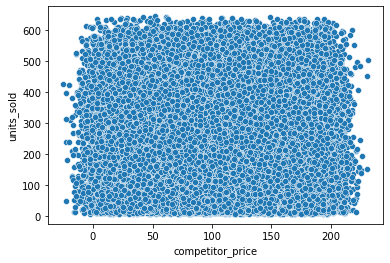

In [6]:
sns.scatterplot(x='competitor_price',y="units_sold",data=df)
plt.show()

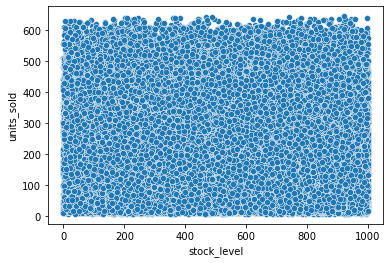

In [7]:
sns.scatterplot(x="stock_level", y="units_sold", data=df)
plt.show()

In [8]:
df.head()

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,season,day_of_week,customer_rating,units_sold,optimal_price
0,1102,15.46,22.09,281,104,4773.30,winter,thursday,3.30,267,18.51
1,1435,29.58,17.53,191,122,2638.04,monsoon,thursday,4.53,141,29.76
2,1860,123.77,129.09,390,376,4808.98,monsoon,thursday,2.78,287,126.66
3,1270,123.38,135.49,424,449,1857.01,festival,wednesday,2.74,475,125.46
4,1106,55.74,70.18,107,644,1053.16,summer,monday,3.47,84,57.67


In [9]:
df['price_gap']=df['current_price']-df['competitor_price']

In [10]:
df.head()

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,season,day_of_week,customer_rating,units_sold,optimal_price,price_gap
0,1102,15.46,22.09,281,104,4773.30,winter,thursday,3.30,267,18.51,-6.63
1,1435,29.58,17.53,191,122,2638.04,monsoon,thursday,4.53,141,29.76,12.05
2,1860,123.77,129.09,390,376,4808.98,monsoon,thursday,2.78,287,126.66,-5.32
3,1270,123.38,135.49,424,449,1857.01,festival,wednesday,2.74,475,125.46,-12.11
4,1106,55.74,70.18,107,644,1053.16,summer,monday,3.47,84,57.67,-14.44


In [11]:
df["stock_to_demand_ratio"] = df["stock_level"] / (df["demand_last_week"] + 1)

In [12]:
df.head()

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,season,day_of_week,customer_rating,units_sold,optimal_price,price_gap,stock_to_demand_ratio
0,1102,15.46,22.09,281,104,4773.30,winter,thursday,3.30,267,18.51,-6.63,0.368794
1,1435,29.58,17.53,191,122,2638.04,monsoon,thursday,4.53,141,29.76,12.05,0.635417
2,1860,123.77,129.09,390,376,4808.98,monsoon,thursday,2.78,287,126.66,-5.32,0.961637
3,1270,123.38,135.49,424,449,1857.01,festival,wednesday,2.74,475,125.46,-12.11,1.056471
4,1106,55.74,70.18,107,644,1053.16,summer,monday,3.47,84,57.67,-14.44,5.962963


In [13]:
df["is_weekend"] = df["day_of_week"].isin(["saturday","sunday"]).astype(int)

In [14]:
df.head()

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,season,day_of_week,customer_rating,units_sold,optimal_price,price_gap,stock_to_demand_ratio,is_weekend
0,1102,15.46,22.09,281,104,4773.30,winter,thursday,3.30,267,18.51,-6.63,0.368794,0
1,1435,29.58,17.53,191,122,2638.04,monsoon,thursday,4.53,141,29.76,12.05,0.635417,0
2,1860,123.77,129.09,390,376,4808.98,monsoon,thursday,2.78,287,126.66,-5.32,0.961637,0
3,1270,123.38,135.49,424,449,1857.01,festival,wednesday,2.74,475,125.46,-12.11,1.056471,0
4,1106,55.74,70.18,107,644,1053.16,summer,monday,3.47,84,57.67,-14.44,5.962963,0


# #Encode Categorical Variables

In [15]:
df=pd.get_dummies(df,columns=['season','day_of_week'],drop_first=True)

In [16]:
df.head()

,product_id,current_price,competitor_price,demand_last_week,stock_level,marketing_spend,customer_rating,units_sold,optimal_price,price_gap,...,is_weekend,season_monsoon,season_summer,season_winter,day_of_week_monday,day_of_week_saturday,day_of_week_sunday,day_of_week_thursday,day_of_week_tuesday,day_of_week_wednesday
0,1102,15.46,22.09,281,104,4773.30,3.30,267,18.51,-6.63,...,0,0,0,1,0,0,0,1,0,0
1,1435,29.58,17.53,191,122,2638.04,4.53,141,29.76,12.05,...,0,1,0,0,0,0,0,1,0,0
2,1860,123.77,129.09,390,376,4808.98,2.78,287,126.66,-5.32,...,0,1,0,0,0,0,0,1,0,0
3,1270,123.38,135.49,424,449,1857.01,2.74,475,125.46,-12.11,...,0,0,0,0,0,0,0,0,0,1
4,1106,55.74,70.18,107,644,1053.16,3.47,84,57.67,-14.44,...,0,0,1,0,1,0,0,0,0,0


In [17]:
X=df.drop('optimal_price',axis=1)
y=df['optimal_price']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.fit_transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor
from sklearn.tree import  DecisionTreeClassifier
from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score


C:\Users\jigar\anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
C:\Users\jigar\anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
C:\Users\jigar\anaconda3\lib\site-packages\dask\dataframe\utils.py:369: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [21]:
models={"Linear Regression":LinearRegression(),
       "random forest":RandomForestRegressor(),
       "Gradient":GradientBoostingRegressor(),
       "xg":XGBRegressor(),
       "lightgbm":LGBMRegressor()}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    

    print("Model:", name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-----------------------")
     

Model: Linear Regression
MAE: 0.09982208347117584
RMSE: 0.1209558166047798
R2 Score: 0.9999953468605651
-----------------------
Model: random forest
MAE: 0.21809200000000203
RMSE: 0.29603988622747623
R2 Score: 0.9999721264035392
-----------------------
Model: Gradient
MAE: 0.39470813622846973
RMSE: 0.4968666524834261
R2 Score: 0.9999214814536772
-----------------------
Model: xg
MAE: 0.2548970920926875
RMSE: 0.31681746470997646
R2 Score: 0.9999680764794585
-----------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2575
[LightGBM] [Info] Number of data points in the train set: 33500, number of used features: 20
[LightGBM] [Info] Start training from score 103.562681
Model: lightgbm
MAE: 0.229160950899192
RMSE: 0.2818479804532689
R2 Score: 0.9999747348194831
--------------

## overfitting by comparing train vs test R².

In [22]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9999824754153734
Test R2: 0.9999747348194831


## Using Pipe Line 


In [23]:
from sklearn.pipeline import Pipeline

In [24]:
models={"Linear Regression":LinearRegression(),
       "random forest":RandomForestRegressor(),
       "Gradient":GradientBoostingRegressor(),
       "xg":XGBRegressor(),
       "lightgbm":LGBMRegressor()}

best_lr_model = None

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    print("Model:", name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("------------------------")


Model: Linear Regression
MAE: 0.09982208347111465
RMSE: 0.1209558166047101
R2 Score: 0.9999953468605651
------------------------
Model: random forest
MAE: 0.2182797696969712
RMSE: 0.29528928485110995
R2 Score: 0.9999722675698974
------------------------
Model: Gradient
MAE: 0.39470813622846884
RMSE: 0.4968666524834246
R2 Score: 0.9999214814536772
------------------------
Model: xg
MAE: 0.2548970920926875
RMSE: 0.31681746470997646
R2 Score: 0.9999680764794585
------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2575
[LightGBM] [Info] Number of data points in the train set: 33500, number of used features: 20
[LightGBM] [Info] Start training from score 103.562681
Model: lightgbm
MAE: 0.229160950899192
RMSE: 0.2818479804532689
R2 Score: 0.9999747348194831
-----------